# HAPY Failures

- quantify how failures vary with stellar mass, etc.

In [1]:
import os
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import Table
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import pandas as pd

from hapy.utils.results_table import prepare_analysis_table

In [12]:
os.chdir('/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260417')
mtab = Table.read("merged_results.fits")
htab = prepare_analysis_table(mtab)

REVIEW_PRIORITY SUMMARY
{'high': 80, 'low': 325, 'medium': 418}
ELL_MISMATCH 269
FILTER_WARNING 79
WARN_MASK 29
BRIGHT_STAR_FLAG 9
WARN_WEAK_HA 297


In [13]:
%run ~/github/Virgo/programs/readtablesv2.py

table directory =  /Users/rfinn/research/Virgo/tables-north/v2/


# Look at failures in SFR - Mstar plane

In [5]:
import hapy.utils.plotting as hplt

(6.0, 12.0)

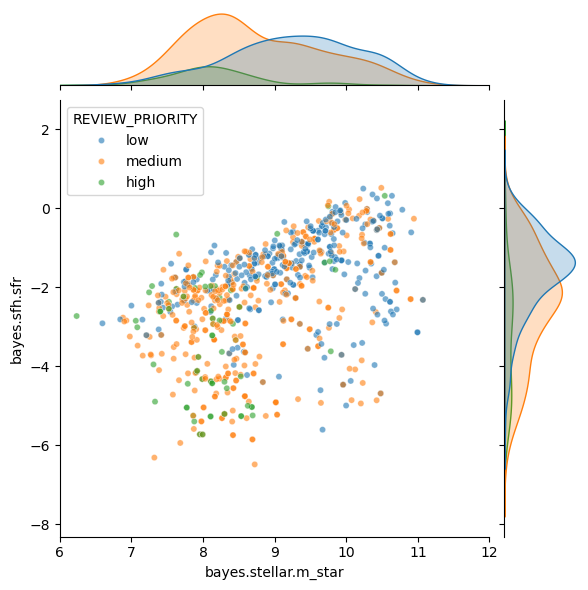

In [17]:
xname = "logMstar_med"
xname = 'bayes.stellar.m_star'
x = np.log10(v.cigale[xname][htab["VFINDEX"]])

yname = "logSFR_med"
yname = 'bayes.sfh.sfr'
y = np.log10(v.cigale[yname][htab["VFINDEX"]])

huecol = "REVIEW_PRIORITY"
category = htab[huecol]

ptab = Table([x,y,category],names=["logMstar","logSFR","REVIEW_PRIORITY"])
df = ptab.to_pandas()

g = hplt.jointplot_with_hue(x,y,category,xname=xname, yname=yname, catname=huecol)

g.ax_joint.set_xlim(6,12)

In [23]:
df

,logMstar,logSFR,REVIEW_PRIORITY
0,9.807,-0.498,low
1,9.722,-1.163,low
2,8.552,-1.143,medium
3,7.437,-1.908,low
4,8.892,-0.958,medium
...,...,...,...
818,8.912,-1.418,low
819,7.567,-0.863,medium
820,9.207,-1.018,low
821,7.182,-3.558,high


In [20]:
xname="x"
yname="y"
catname="category"
good = np.isfinite(x) & np.isfinite(y)
df = pd.DataFrame({
    "x": x[good],
    "y": y[good],
    "category": category[good],
})

9.807
9.722
8.552
7.437
8.892
8.892
8.247
10.44
10.44
9.877
9.877
